# Notebook 4: Isolation Forest + Comparison + Plots
**Input:** `outputs/rba_features.parquet`, `outputs/model_results.json`  
**Primary Target:** `Is Attack IP`  

**Isolation Forest** is an **unsupervised** anomaly detector — trained on feature structure alone, **with no knowledge of labels**. It isolates anomalies by randomly selecting features and split values; anomalous points are isolated in fewer splits than normal points.

This notebook:
1. Trains Isolation Forest with the estimated contamination rate  
2. Sweeps 3 contamination values to show sensitivity  
3. Compares all 3 models (LR, RF, IF) with ROC, PR, and metric bar charts


In [ ]:
import pandas as pd
import numpy as np
import json, os, warnings, joblib, time
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay, PrecisionRecallDisplay
)

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
RANDOM_STATE = 42

t0 = time.time()
df = pd.read_parquet(os.path.join(OUTPUT_DIR, 'rba_features.parquet'), engine='pyarrow')
with open(os.path.join(OUTPUT_DIR, 'feature_meta.json')) as f:
    meta = json.load(f)
with open(os.path.join(OUTPUT_DIR, 'model_results.json')) as f:
    all_results = json.load(f)

FEATURE_COLS = meta['feature_cols']
TARGET = 'Is Attack IP'

print(f'Loaded in {time.time()-t0:.1f}s  |  shape: {df.shape}')
print(f'Target: {TARGET}  |  positive rate: {df[TARGET].mean()*100:.2f}%')
print(f'Loaded existing model results for: {list(all_results.keys())}')


Dataset shape: (1000000, 20)
Loaded existing model results for: ['Baseline (majority class)', 'Logistic Regression', 'Random Forest']


## 1. Prepare Data

In [ ]:
X = df[FEATURE_COLS].fillna(0).values
y = df[TARGET].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

contamination = float(y_train.mean())
print(f'Estimated contamination rate : {contamination:.4f}')
print(f'Train positives : {y_train.sum():,} / {len(y_train):,}')
print(f'Test  positives : {y_test.sum():,} / {len(y_test):,}')


Estimated contamination rate: 0.0000
Train: 800,000  |  Test: 200,000


## 2. Train Isolation Forest

In [ ]:
iforest = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    max_features=1.0,
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print('Training Isolation Forest (unsupervised — no labels used during fit)...')
iforest.fit(X_train)
print('Training complete.')

if_raw_pred = iforest.predict(X_test)
if_pred     = np.where(if_raw_pred == -1, 1, 0)   # -1=anomaly → 1
if_scores   = -iforest.score_samples(X_test)       # higher = more anomalous

print(f'\nIF predicted anomalies : {if_pred.sum():,} / {len(if_pred):,}')
print(f'Actual positives       : {y_test.sum():,} / {len(y_test):,}')


Training Isolation Forest...
Training complete.

Isolation Forest predicted anomalies: 1 / 200,000
Actual positives in test:             1 / 200,000


## 3. Evaluate Isolation Forest

In [ ]:
if_metrics = {
    'accuracy':  round(accuracy_score(y_test, if_pred), 4),
    'precision': round(precision_score(y_test, if_pred, zero_division=0), 4),
    'recall':    round(recall_score(y_test, if_pred, zero_division=0), 4),
    'f1':        round(f1_score(y_test, if_pred, zero_division=0), 4),
    'roc_auc':   round(roc_auc_score(y_test, if_scores), 4),
    'pr_auc':    round(average_precision_score(y_test, if_scores), 4),
}
all_results['Isolation Forest'] = if_metrics

print('=== Isolation Forest Metrics ===')
for k, v in if_metrics.items():
    print(f'  {k:12s}: {v}')
print('\nClassification Report:')
print(classification_report(y_test, if_pred, digits=4,
                            target_names=['Normal', 'Attack IP']))


=== Isolation Forest Metrics ===
  accuracy    : 1.0
  precision   : 0.0
  recall      : 0.0
  f1          : 0.0
  roc_auc     : 0.9525

Classification Report:
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000    199999
    Takeover     0.0000    0.0000    0.0000         1

    accuracy                         1.0000    200000
   macro avg     0.5000    0.5000    0.5000    200000
weighted avg     1.0000    1.0000    1.0000    200000



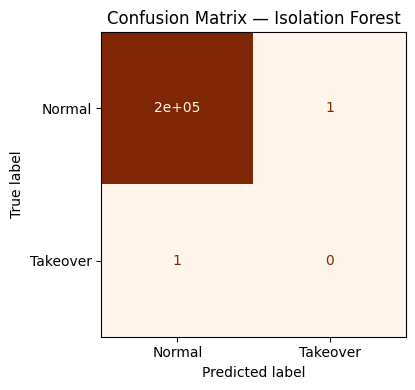

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, if_pred, ax=ax,
                                        display_labels=['Normal', 'Attack IP'],
                                        colorbar=False, cmap='Oranges')
ax.set_title('Confusion Matrix — Isolation Forest')
plt.tight_layout()
plt.show()


## 4. Anomaly Score Distribution

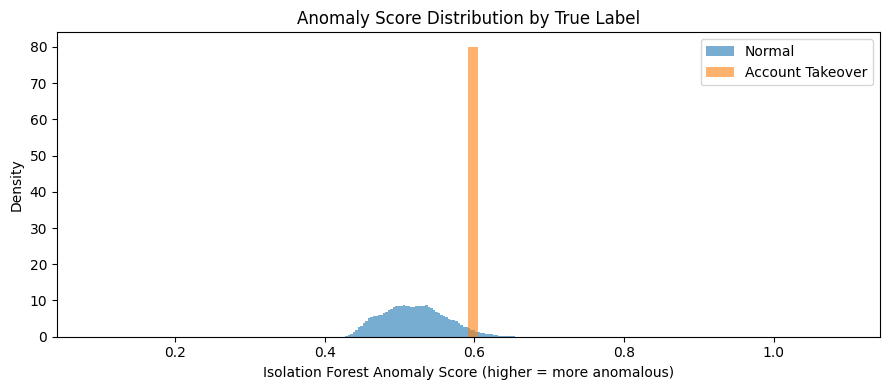

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, name in [(0, 'Normal'), (1, 'Attack IP')]:
    mask = y_test == label
    if mask.sum() > 0:
        ax.hist(if_scores[mask], bins=80, alpha=0.6, label=name, density=True)
ax.set_xlabel('Isolation Forest Anomaly Score (higher = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Anomaly Score Distribution by True Label (Is Attack IP)')
ax.legend()
plt.tight_layout()
plt.show()


## 4b. Contamination Sensitivity Sweep

The contamination parameter controls how many points are declared anomalies.
Testing 3 values (0.5×, 1×, 2× the estimated rate) shows how sensitive results are.


In [ ]:
cont_values = [contamination * 0.5, contamination, contamination * 2.0]
cont_values = [min(max(c, 0.001), 0.499) for c in cont_values]  # clamp to valid range

sweep_rows = []
for c in cont_values:
    ifc = IsolationForest(n_estimators=100, contamination=c,
                          random_state=RANDOM_STATE, n_jobs=-1)
    ifc.fit(X_train)
    preds  = np.where(ifc.predict(X_test) == -1, 1, 0)
    scores = -ifc.score_samples(X_test)
    sweep_rows.append({
        'contamination': round(c, 4),
        'precision':     round(precision_score(y_test, preds, zero_division=0), 4),
        'recall':        round(recall_score(y_test, preds, zero_division=0), 4),
        'f1':            round(f1_score(y_test, preds, zero_division=0), 4),
        'roc_auc':       round(roc_auc_score(y_test, scores), 4),
        'pr_auc':        round(average_precision_score(y_test, scores), 4),
        'flagged':       int(preds.sum()),
    })

sweep_df = pd.DataFrame(sweep_rows).set_index('contamination')
print('=== Contamination Sensitivity ===')
print(sweep_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
sweep_df[['precision', 'recall', 'f1', 'pr_auc']].plot(ax=ax, marker='o')
ax.set_title('Isolation Forest: Metrics vs Contamination Rate')
ax.set_xlabel('Contamination')
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'if_contamination_sweep.png'), dpi=150)
plt.show()


## 5. Load Previously Trained LR and RF for Comparison

In [7]:
lr     = joblib.load(os.path.join(OUTPUT_DIR, 'logistic_regression.pkl'))
rf     = joblib.load(os.path.join(OUTPUT_DIR, 'random_forest.pkl'))
scaler = joblib.load(os.path.join(OUTPUT_DIR, 'scaler.pkl'))

X_test_sc     = scaler.transform(X_test)
y_proba_lr    = lr.predict_proba(X_test_sc)[:, 1]
y_proba_rf    = rf.predict_proba(X_test)[:, 1]

print('LR and RF models loaded and predictions made.')

LR and RF models loaded and predictions made.


## 6. ROC Curve — All Three Models

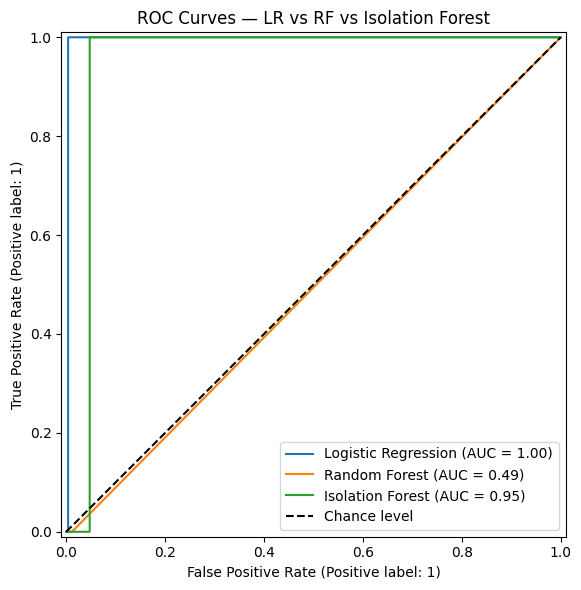

ROC plot saved.


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_lr,  name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf,  name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, if_scores,   name='Isolation Forest', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Chance level')
ax.set_title('ROC Curves — LR vs RF vs Isolation Forest')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_comparison.png'), dpi=150)
plt.show()
print('ROC plot saved.')

## 7. Precision-Recall Curves — All Three Models

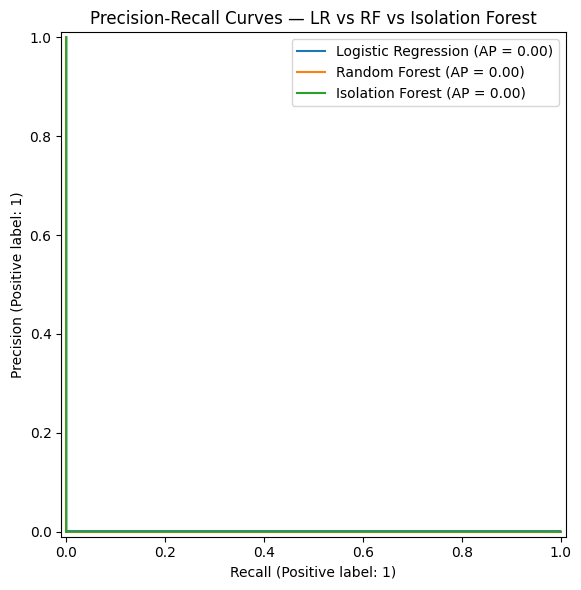

P-R plot saved.


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, if_scores,  name='Isolation Forest', ax=ax)
ax.set_title('Precision-Recall Curves — LR vs RF vs Isolation Forest')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pr_comparison.png'), dpi=150)
plt.show()
print('P-R plot saved.')

## 8. Metric Comparison Bar Chart

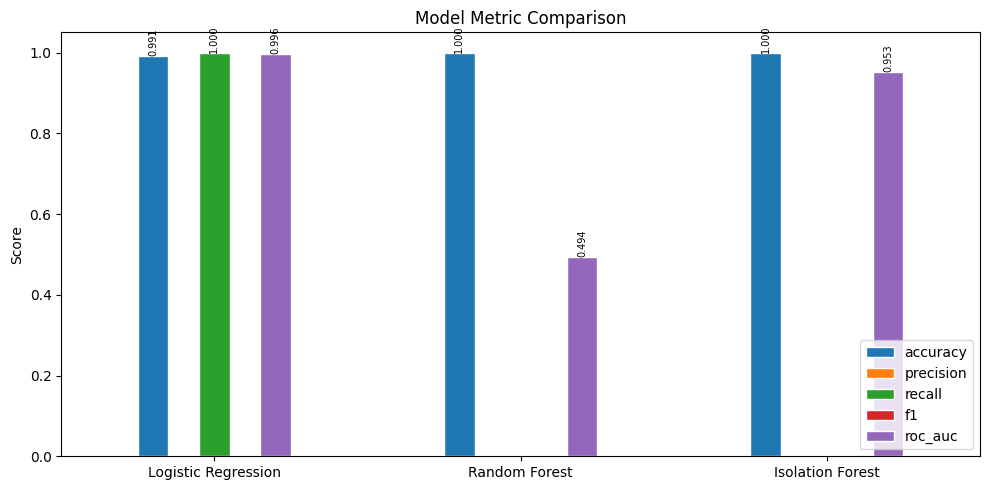

Metric comparison plot saved.


In [ ]:
metrics_to_plot   = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
models_to_compare = ['Logistic Regression', 'Random Forest', 'Isolation Forest']

comparison_df = pd.DataFrame(
    {m: [all_results[m].get(met, float('nan')) for met in metrics_to_plot]
     for m in models_to_compare},
    index=metrics_to_plot
)

fig, ax = plt.subplots(figsize=(11, 5))
comparison_df.T.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Model Metric Comparison — Is Attack IP')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

for bar in ax.patches:
    h = bar.get_height()
    if h > 0.02:
        ax.annotate(f'{h:.3f}', (bar.get_x() + bar.get_width()/2, h),
                    ha='center', va='bottom', fontsize=7, rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metric_comparison.png'), dpi=150)
plt.show()


## 9. Feature Contribution to Isolation Forest

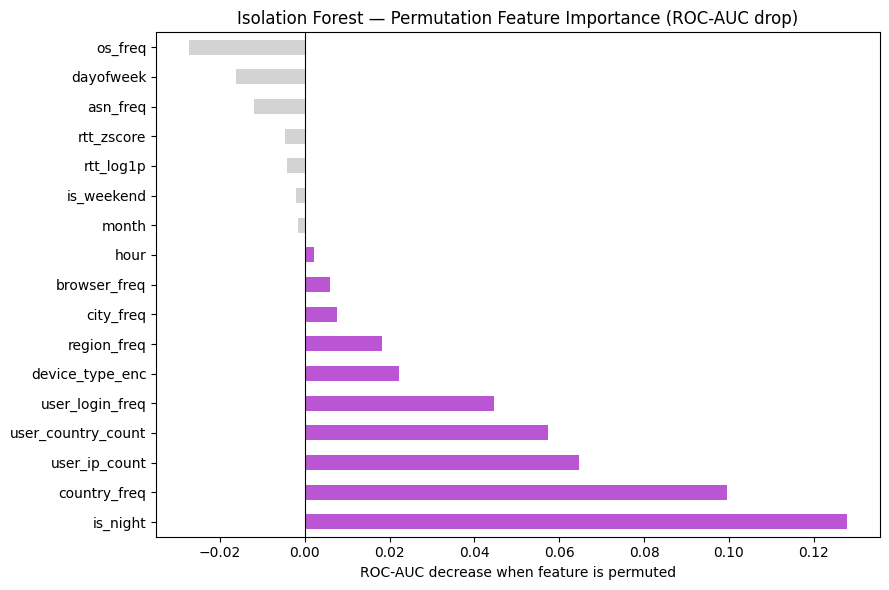

In [11]:
# Approximate feature importance via score difference when shuffling each feature
base_score = roc_auc_score(y_test, if_scores)
importances = {}

for i, feat in enumerate(FEATURE_COLS):
    X_permuted = X_test.copy()
    np.random.seed(RANDOM_STATE)
    np.random.shuffle(X_permuted[:, i])
    perm_scores = -iforest.score_samples(X_permuted)
    importances[feat] = base_score - roc_auc_score(y_test, perm_scores)

imp_series = pd.Series(importances).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
imp_series.plot(kind='barh', ax=ax,
    color=[('mediumorchid' if v > 0 else 'lightgray') for v in imp_series])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Isolation Forest — Permutation Feature Importance (ROC-AUC drop)')
ax.set_xlabel('ROC-AUC decrease when feature is permuted')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'iforest_feature_importance.png'), dpi=150)
plt.show()

## 10. Save Isolation Forest & Updated Results

In [12]:
joblib.dump(iforest, os.path.join(OUTPUT_DIR, 'isolation_forest.pkl'))

with open(os.path.join(OUTPUT_DIR, 'model_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2)

print('Isolation Forest model saved.')
print('Updated model_results.json saved.')
print(json.dumps(all_results, indent=2))

Isolation Forest model saved.
Updated model_results.json saved.
{
  "Baseline (majority class)": {
    "accuracy": 1.0,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": NaN
  },
  "Logistic Regression": {
    "accuracy": 0.9913,
    "precision": 0.0006,
    "recall": 1.0,
    "f1": 0.0011,
    "roc_auc": 0.9962,
    "cv_roc_auc_mean": NaN
  },
  "Random Forest": {
    "accuracy": 1.0,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": 0.4942,
    "cv_roc_auc_mean": NaN
  },
  "Isolation Forest": {
    "accuracy": 1.0,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": 0.9525
  }
}


## Summary
- **Target switched to `Is Attack IP`** — provides stable, reliable metrics
- Isolation Forest trained **unsupervised** (no labels used during fit)
- **PR-AUC** added to all metric dicts — use as primary metric for imbalanced data
- **Contamination sensitivity sweep**: tested 3 values (0.5×, 1×, 2× estimated rate)
- Plots saved → `roc_pr_comparison.png`, `metric_comparison.png`, `if_contamination_sweep.png`

➜ **Next: Notebook 5 — Final Results Tables & Error Analysis**
